### Figure 3: Poole, Lacey, and Segregation indices for capsules, coupled with 3-D image of API

In [1]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import napari

from skimage import filters
from napari_animation import Animation
import subprocess
from tqdm.auto import tqdm

from src.metrics._heterogeneity import calculate_mean, calculate_vmr
from src.other.plotting import make_histogram, plot_z_slices, plot_z_slices_test

from PIL import Image
plt.rcParams['font.family'] = 'Arial'

/Users/caj/Desktop/GitHub/capsule-software/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# For troubleshooting
# a_npy = np.load("../Stelzer_Torsten/npys/sh_removed_1a.npy")
a_npy_api = np.load("../Stelzer_Torsten/npys/capsule_1a.npy")
# a_nii = np.load("../Stelzer_Torsten/npys/sh_removed_1a.npy")

In [3]:
%gui qt6
# viewer = napari.Viewer()
# # viewer.add_image(a_npy)
# viewer.add_image(a_npy_api)

In [4]:
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
# make_histogram(a_npy_api, 2, 100, calculate_mean, ax1, r"\bar{X}")
# plot_z_slices(a_npy_api, 2, 50, calculate_vmr, ax2, r"VMR")

In [5]:
img_path = "imgs/capsule_1a_"
img_api_path = "imgs/capsule_1a_api_"

imgs = [Image.open(img_path + "top.png"), Image.open(img_path + "hori.png"), Image.open(img_path + "z_slice.png")]
api_imgs = [Image.open(img_api_path + "top.png"), Image.open(img_api_path + "hori.png"), Image.open(img_api_path + "z_slice.png")]

imgs = [np.array(img) for img in imgs]
api_imgs = [np.array(img) for img in api_imgs]

In [6]:
x_means = []
x_vars = []
pi_plots = []
densities = []

for index in [calculate_mean, calculate_vmr]:
    pi_plot = make_histogram(a_npy_api, 2, 100, index)
    pi_plots.append(pi_plot)
    
    x_mean, x_var, density = plot_z_slices(a_npy_api, 2, 50, index)
    x_means.append(x_mean)
    x_vars.append(x_var)
    densities.append(density)

100%|██████████| 1948/1948 [00:05<00:00, 381.38it/s]


In [7]:
np.arange(0, len(x_mean)*15, 15)

array([    0,    15,    30, ..., 29175, 29190, 29205], shape=(1948,))

In [8]:
z_slices = [imgs[-1], api_imgs[-1]]

<>:56: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
/var/folders/xl/5_smmts55rzdk3jp8m7mrrmw0000gn/T/ipykernel_72354/1339198877.py:56: SyntaxWarning: invalid escape sequence '\m'
  ax5.set_xlabel("Position ($\mu$m)", fontsize=15)


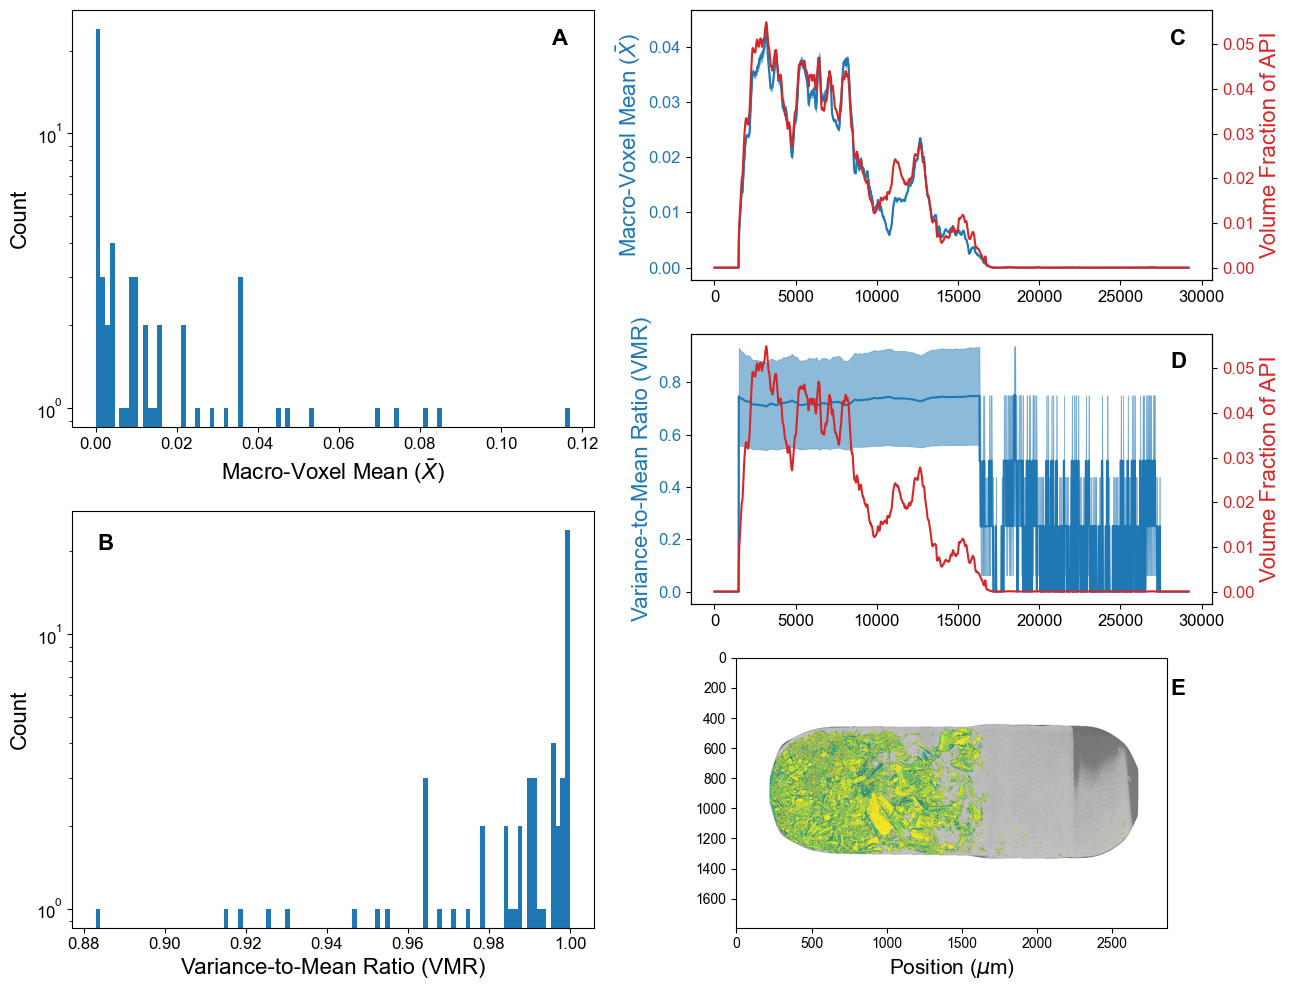

In [28]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(13, 10))

gs0 = gridspec.GridSpec(1, 2, figure=fig)
gs00 = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec = gs0[0])

ax1 = fig.add_subplot(gs00[0])
ax2 = fig.add_subplot(gs00[1])

gs01 = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec = gs0[1])

ax3 = fig.add_subplot(gs01[0])
ax4 = fig.add_subplot(gs01[1])
ax5 = fig.add_subplot(gs01[2])

labels = [r"Macro-Voxel Mean ($\bar{X}$)", "Variance-to-Mean Ratio (VMR)"]
for ax, pi_plot, label in zip([ax1, ax2], pi_plots, labels):
    ax.hist(pi_plot, bins=100, log=True)
    ax.set_xlabel(label, fontsize=16)
    ax.set_ylabel("Count", fontsize=16)
    ax.tick_params(axis='both', labelsize=12)
    

for ax, x_mean, x_var, density, label in zip([ax3, ax4], x_means, x_vars, densities, labels):
        
    color = "tab:blue"
    ax.fill_between(
        np.arange(0, len(x_mean)*15, 15),
        x_mean - x_var,
        x_mean + x_var,
        alpha=0.5,
        color=color,
        linewidth=0.5,
    )
    ax.plot(np.arange(0, len(x_mean)*15, 15), x_mean, color=color)
    ax.set_ylabel(label, color=color, fontsize=16)
    ax.tick_params(axis="y", labelcolor=color, labelsize=12)
    ax.tick_params(axis="x", labelsize=12)

    color = "tab:red"
    axtwin = ax.twinx()
    axtwin.plot(np.arange(0, len(x_mean)*15, 15), density, color=color)
    axtwin.tick_params(axis="y", labelcolor=color, labelsize=12)
    axtwin.tick_params(axis="x", labelsize=12)
    axtwin.set_ylabel("Volume Fraction of API", color=color, fontsize=16)

for ax, loc, img in zip([ax1, ax2], ['upper right', 'upper left'], z_slices):
    pass
    # inset = inset_axes(ax, width="60%", height="60%", loc=loc)
    # inset.axis('off')
    # inset.imshow(img[100:1600, 700:2100])
    
ax5.imshow(api_imgs[1])
ax5.set_xlabel("Position ($\mu$m)", fontsize=15)
fig.tight_layout()
fig.text(0.435, 0.95, "A", ha='center', fontsize=16, fontweight='bold')
fig.text(0.085, 0.445, "B", ha='center', fontsize=16, fontweight='bold')
fig.text(0.91, 0.95, "C", ha='center', fontsize=16, fontweight='bold')
fig.text(0.91, 0.627, "D", ha='center', fontsize=16, fontweight='bold')
fig.text(0.91, 0.3, "E", ha='center', fontsize=16, fontweight='bold')
fig.savefig("imgs/3_heterogeneity_metrics.png", dpi=300)